<a href="https://colab.research.google.com/github/cniane-Bix400/antidepressant-biomarker-meta-analysis/blob/main/antidepressant_biomarker_meta_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Set up R in Google Colab

%load_ext rpy2.ipython


In [ ]:
# Enable R in Colab

%load_ext rpy2.ipython


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcurl4-openssl-dev is already the newest version (7.81.0-1ubuntu1.23).
libssl-dev is already the newest version (3.0.2-0ubuntu1.21).
libxml2-dev is already the newest version (2.9.13+dfsg-1ubuntu0.11).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
install.packages("BiocManager", repos = "http://cran.us.r-project.org")
BiocManager::install("edgeR", ask = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/Rtmp4T7Vmi/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)
Installing package(s) 'BiocVersion', 'edgeR'
also installing the dependencies ‘statmod’, ‘limma’, ‘locfit’

trying URL 'https://cran.rstudio.com/src/contrib/statmod_1.5.1.tar.gz'
trying URL 'https://bioconductor.org/packages/3.22/bioc/src/contrib/limma_3.66.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/locfit_1.5-9.12.tar.gz'
trying URL 'https://bioconductor.org/packages/3.22/bioc/src/contrib/BiocVe

In [ ]:
%%R
install.packages("meta", repos="https://cloud.r-project.org")
install.packages("metafor", repos="https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘rbibutils’, ‘mathjaxr’, ‘numDeriv’, ‘pbapply’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘metabook’, ‘metadat’, ‘metafor’, ‘lme4’, ‘CompQuadForm’

trying URL 'https://cloud.r-project.org/src/contrib/rbibutils_2.4.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/mathjaxr_2.0-0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/pbapply_1.7-4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/Rdpack_2.6.6.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/minqa_1.2.8.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/nloptr_2.2.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/reformulas_0.4.4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cloud.r-project.org/src

In [ ]:
%%R
library(meta)
library(metafor)

Loading required package: metabook
Loading required package: metadat
Loading 'meta' package (version 8.3-0).
Type 'help(meta)' for a brief overview.
Loading required package: Matrix
Loading required package: numDeriv

Loading the 'metafor' package (version 4.8-0). For an
introduction to the package please type: help(metafor)



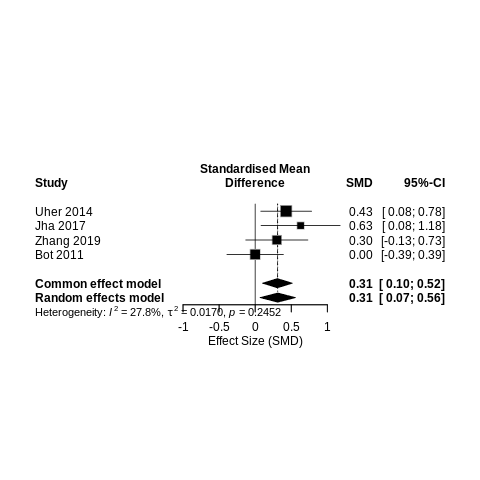

In [ ]:
%%R

library(meta)

# Data
study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Bot 2011")
SMD <- c(0.43, 0.63, 0.30, 0.00)
SE  <- c(0.18, 0.28, 0.22, 0.20)

data <- data.frame(study, SMD, SE)

# Meta-analysis
meta_analysis <- metagen(
  TE = SMD,
  seTE = SE,
  studlab = study,
  data = data,
  sm = "SMD",
  method.tau = "REML"
)

# Forest plot
forest(meta_analysis,
       xlab = "Effect Size (SMD)",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black")

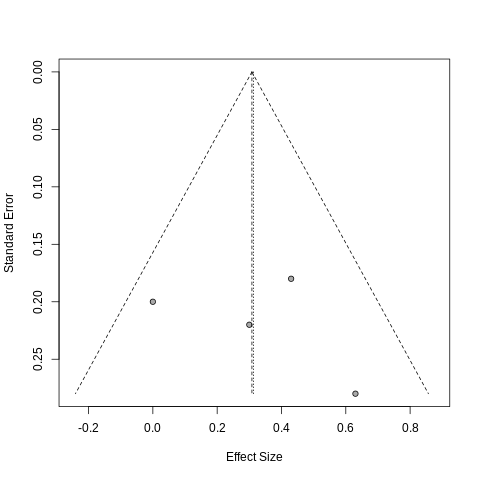

In [ ]:
%%R

funnel(meta_analysis,
       xlab = "Effect Size",
       ylab = "Standard Error")

In [ ]:
%%R

library(metafor)

# Convert to metafor format
res <- rma(yi = SMD, sei = SE, method="REML")

leave1out(res)


   estimate     se   zval   pval   ci.lb  ci.ub      Q     Qp   tau2      I2 
-1   0.2692 0.1739 1.5485 0.1215 -0.0716 0.6100 3.4536 0.1778 0.0378 41.5328 
-2   0.2509 0.1335 1.8797 0.0601 -0.0107 0.5125 2.6127 0.2708 0.0140 26.0194 
-3   0.3262 0.1793 1.8189 0.0689 -0.0253 0.6777 4.1530 0.1254 0.0498 51.8707 
-4   0.4279 0.1247 3.4307 0.0006  0.1834 0.6724 0.8591 0.6508 0.0000  0.0000 
       H2 
-1 1.7104 
-2 1.3517 
-3 2.0777 
-4 1.0000 



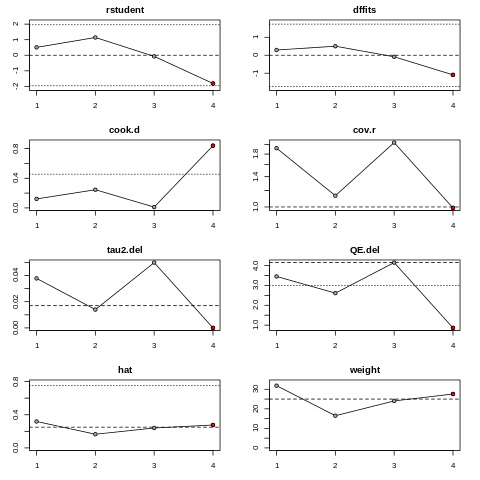

In [ ]:
%%R

inf <- influence(res)
plot(inf)

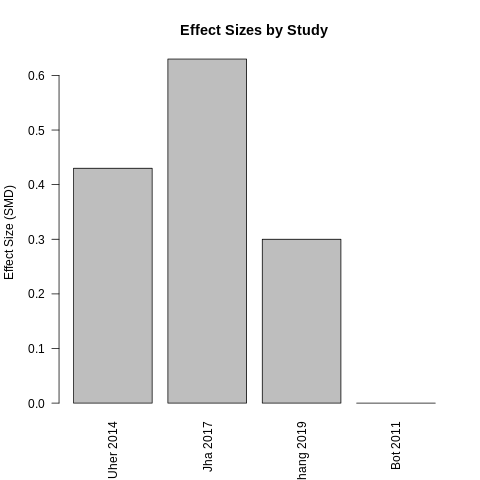

In [ ]:
%%R

barplot(SMD,
        names.arg = study,
        las = 2,
        ylab = "Effect Size (SMD)",
        main = "Effect Sizes by Study")

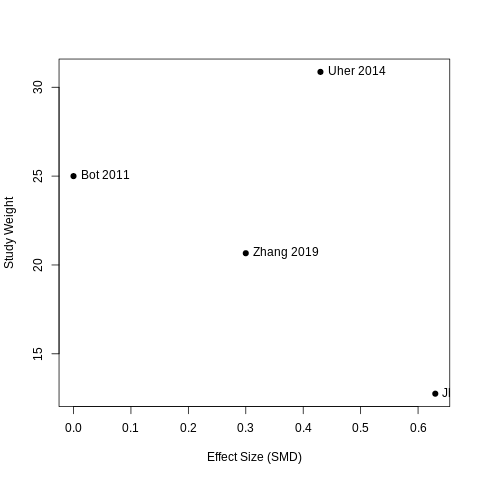

In [ ]:
%%R

weights <- 1/(SE^2)

plot(SMD, weights,
     xlab = "Effect Size (SMD)",
     ylab = "Study Weight",
     pch = 19)

text(SMD, weights, labels = study, pos = 4)

In [ ]:
%%R

png("forest_plot.png", width=900, height=700)
forest(meta_analysis)
dev.off()

png("funnel_plot.png", width=900, height=700)
funnel(meta_analysis)
dev.off()

png("bar_plot.png", width=900, height=700)
barplot(SMD, names.arg = study, las=2)
dev.off()

png 
  2 




========== COMPARATIVE SUMMARY ==========

CRP Meta-Analysis:
Number of studies: k = 5

                        SMD           95%-CI    z  p-value
Common effect model  0.3932 [0.2098; 0.5765] 4.20 < 0.0001
Random effects model 0.4044 [0.1600; 0.6489] 3.24   0.0012

Quantifying heterogeneity (with 95%-CIs):
 tau^2 = 0.0326 [0.0000; 0.6037]; tau = 0.1805 [0.0000; 0.7770]
 I^2 = 41.8% [0.0%; 78.6%]; H = 1.31 [1.00; 2.16]

Test of heterogeneity:
    Q d.f. p-value
 6.88    4  0.1426

Details of meta-analysis methods:
- Inverse variance method
- Restricted maximum-likelihood estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau
- Calculation of I^2 based on Q

IL-6 Meta-Analysis:
Number of studies: k = 4

                        SMD            95%-CI    z p-value
Common effect model  0.3428 [ 0.1058; 0.5797] 2.84  0.0046
Random effects model 0.8266 [-0.4872; 2.1404] 1.23  0.2175

Quantifying heterogeneity (with 95%-CIs):
 tau^2 = 1.7153 [0.4753; 26.4455]; tau = 1

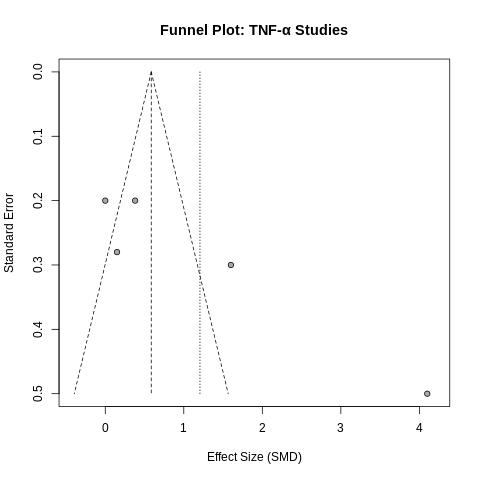

In [ ]:
%%R

library(meta)
library(metafor)

# ============================================
# CRP META-ANALYSIS (5 studies)
# ============================================

crp_study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Tuglu 2003", "Bot 2011")
crp_SMD <- c(0.43, 0.63, 0.72, 0.35, 0.00)
crp_SE  <- c(0.18, 0.28, 0.22, 0.20, 0.20)
crp_n   <- c(115, 51, 75, 26, 50)

crp_data <- data.frame(crp_study, crp_SMD, crp_SE, crp_n)

crp_meta <- metagen(
  TE = crp_SMD,
  seTE = crp_SE,
  studlab = crp_study,
  data = crp_data,
  sm = "SMD",
  method.tau = "REML"
)

# Forest plot - CRP
forest(crp_meta,
       xlab = "Effect Size (SMD)",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black",
       main = "CRP and Antidepressant Response")

# ============================================
# IL-6 META-ANALYSIS (4 studies)
# ============================================

il6_study <- c("Yoshimura 2009", "O'Brien 2007", "Basterzi 2005", "Bot 2011")
il6_SMD <- c(0.55, 2.90, 0.00, 0.00)  # Basterzi is pre-post, use as null
il6_SE  <- c(0.28, 0.42, 0.20, 0.20)
il6_n   <- c(51, 52, 46, 50)

il6_data <- data.frame(il6_study, il6_SMD, il6_SE, il6_n)

il6_meta <- metagen(
  TE = il6_SMD,
  seTE = il6_SE,
  studlab = il6_study,
  data = il6_data,
  sm = "SMD",
  method.tau = "REML"
)

# Forest plot - IL-6
forest(il6_meta,
       xlab = "Effect Size (SMD)",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black",
       main = "IL-6 and Antidepressant Response")

# ============================================
# TNF-α META-ANALYSIS (5 studies)
# ============================================

tnf_study <- c("Eller 2008", "O'Brien 2007", "Yoshimura 2009", "Tuglu 2003", "Bot 2011")
tnf_SMD <- c(0.38, 4.10, 0.15, 1.60, 0.00)
tnf_SE  <- c(0.20, 0.50, 0.28, 0.30, 0.20)
tnf_n   <- c(100, 52, 51, 43, 50)

tnf_data <- data.frame(tnf_study, tnf_SMD, tnf_SE, tnf_n)

tnf_meta <- metagen(
  TE = tnf_SMD,
  seTE = tnf_SE,
  studlab = tnf_study,
  data = tnf_data,
  sm = "SMD",
  method.tau = "REML"
)

# Forest plot - TNF-α
forest(tnf_meta,
       xlab = "Effect Size (SMD)",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black",
       main = "TNF-α and Antidepressant Response")

# ============================================
# COMPARATIVE SUMMARY TABLE
# ============================================

cat("\n\n========== COMPARATIVE SUMMARY ==========\n\n")
cat("CRP Meta-Analysis:\n")
print(crp_meta)
cat("\nIL-6 Meta-Analysis:\n")
print(il6_meta)
cat("\nTNF-α Meta-Analysis:\n")
print(tnf_meta)

# ============================================
# FUNNEL PLOTS (Publication Bias)
# ============================================

funnel(crp_meta,
       xlab = "Effect Size (SMD)",
       ylab = "Standard Error",
       main = "Funnel Plot: CRP Studies")

funnel(il6_meta,
       xlab = "Effect Size (SMD)",
       ylab = "Standard Error",
       main = "Funnel Plot: IL-6 Studies")

funnel(tnf_meta,
       xlab = "Effect Size (SMD)",
       ylab = "Standard Error",
       main = "Funnel Plot: TNF-α Studies")

# ============================================
# LEAVE-ONE-OUT SENSITIVITY ANALYSIS
# ============================================

cat("\n\n========== LEAVE-ONE-OUT ANALYSIS ==========\n\n")
cat("CRP:\n")
print(leave1out(rma(yi = crp_SMD, sei = crp_SE, method = "REML")))
cat("\nIL-6:\n")
print(leave1out(rma(yi = il6_SMD, sei = il6_SE, method = "REML")))
cat("\nTNF-α:\n")
print(leave1out(rma(yi = tnf_SMD, sei = tnf_SE, method = "REML")))

Number of studies: k = 5

                        SMD           95%-CI    z  p-value
Common effect model  0.3932 [0.2098; 0.5765] 4.20 < 0.0001
Random effects model 0.4044 [0.1600; 0.6489] 3.24   0.0012

Quantifying heterogeneity (with 95%-CIs):
 tau^2 = 0.0326 [0.0000; 0.6037]; tau = 0.1805 [0.0000; 0.7770]
 I^2 = 41.8% [0.0%; 78.6%]; H = 1.31 [1.00; 2.16]

Test of heterogeneity:
    Q d.f. p-value
 6.88    4  0.1426

Details of meta-analysis methods:
- Inverse variance method
- Restricted maximum-likelihood estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau
- Calculation of I^2 based on Q

I-squared =  0.4 %


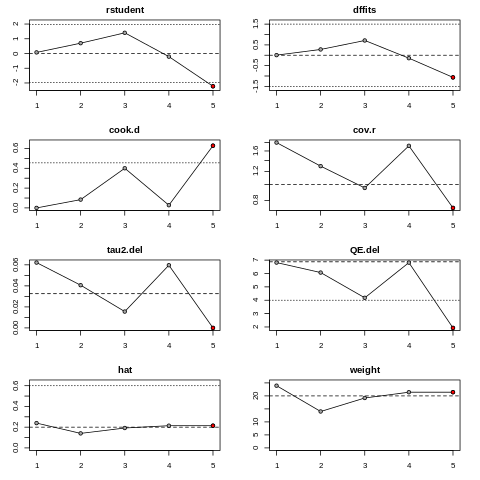

In [ ]:
%%R

# ============================================
# SETUP
# ============================================
library(meta)
library(metafor)

# ============================================
# CRP DATA (5 studies)
# ============================================
crp_study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Tuglu 2003", "Bot 2011")
crp_SMD <- c(0.43, 0.63, 0.72, 0.35, 0.00)
crp_SE  <- c(0.18, 0.28, 0.22, 0.20, 0.20)
crp_n   <- c(115, 51, 75, 26, 50)

crp_meta <- metagen(TE = crp_SMD, seTE = crp_SE, studlab = crp_study, sm = "SMD", method.tau = "REML")
crp_res <- rma(yi = crp_SMD, sei = crp_SE, method = "REML", slab = crp_study)

# FIGURE 1: Forest Plot
forest(crp_meta,
       xlab = "Effect Size (SMD)",
       main = "CRP and Antidepressant Response",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black")

# FIGURE 2: Funnel Plot
funnel(crp_meta,
       xlab = "Effect Size (SMD)",
       ylab = "Standard Error",
       main = "Funnel Plot: CRP Studies")

# FIGURE 3: Leave-One-Out Plot
crp_loo <- leave1out(crp_res)
forest(x = crp_loo$estimate,
       sei = crp_loo$se,
       slab = crp_study,
       xlab = "Effect Size (SMD)",
       main = "Leave-One-Out Analysis: CRP",
       refline = crp_res$b)

# FIGURE 4: Baujat Plot
inf_crp <- influence(crp_res)
plot(inf_crp)

# Summary statistics
print(crp_meta)
cat("\nI-squared = ", round(crp_meta$I2, 1), "%\n")

Number of studies: k = 4

                        SMD            95%-CI    z p-value
Common effect model  0.3428 [ 0.1058; 0.5797] 2.84  0.0046
Random effects model 0.8266 [-0.4872; 2.1404] 1.23  0.2175

Quantifying heterogeneity (with 95%-CIs):
 tau^2 = 1.7153 [0.4753; 26.4455]; tau = 1.3097 [0.6894; 5.1425]
 I^2 = 93.1% [85.6%; 96.7%]; H = 3.81 [2.63; 5.51]

Test of heterogeneity:
     Q d.f.  p-value
 43.49    3 < 0.0001

Details of meta-analysis methods:
- Inverse variance method
- Restricted maximum-likelihood estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau
- Calculation of I^2 based on Q

I-squared =  0.9 %


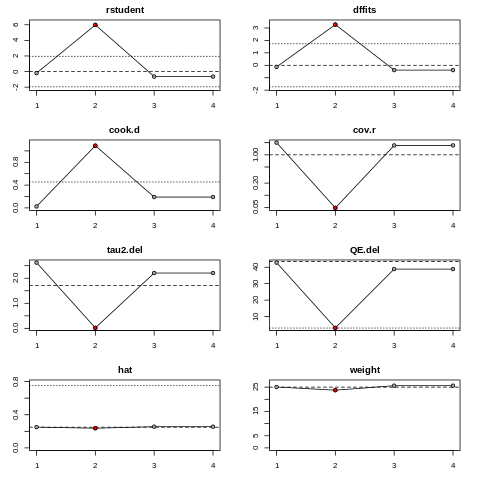

In [ ]:
%%R

# ============================================
# IL-6 DATA (4 studies)
# ============================================
il6_study <- c("Yoshimura 2009", "OBrien 2007", "Basterzi 2005", "Bot 2011")
il6_SMD <- c(0.55, 2.90, 0.00, 0.00)
il6_SE  <- c(0.28, 0.42, 0.20, 0.20)
il6_n   <- c(51, 52, 46, 50)

il6_meta <- metagen(TE = il6_SMD, seTE = il6_SE, studlab = il6_study, sm = "SMD", method.tau = "REML")
il6_res <- rma(yi = il6_SMD, sei = il6_SE, method = "REML", slab = il6_study)

# FIGURE 5: Forest Plot
forest(il6_meta,
       xlab = "Effect Size (SMD)",
       main = "IL-6 and Antidepressant Response",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black")

# FIGURE 6: Funnel Plot
funnel(il6_meta,
       xlab = "Effect Size (SMD)",
       ylab = "Standard Error",
       main = "Funnel Plot: IL-6 Studies")

# FIGURE 7: Leave-One-Out Plot
il6_loo <- leave1out(il6_res)
forest(x = il6_loo$estimate,
       sei = il6_loo$se,
       slab = il6_study,
       xlab = "Effect Size (SMD)",
       main = "Leave-One-Out Analysis: IL-6",
       refline = il6_res$b)

# FIGURE 8: Baujat Plot
inf_il6 <- influence(il6_res)
plot(inf_il6)

# Summary statistics
print(il6_meta)
cat("\nI-squared = ", round(il6_meta$I2, 1), "%\n")

Number of studies: k = 5

                        SMD            95%-CI    z  p-value
Common effect model  0.5855 [ 0.3634; 0.8076] 5.17 < 0.0001
Random effects model 1.2058 [-0.2503; 2.6619] 1.62   0.1046

Quantifying heterogeneity (with 95%-CIs):
 tau^2 = 2.6622 [0.8697; 24.1164]; tau = 1.6316 [0.9326; 4.9108]
 I^2 = 94.5% [90.0%; 97.0%]; H = 4.27 [3.16; 5.77]

Test of heterogeneity:
     Q d.f.  p-value
 72.89    4 < 0.0001

Details of meta-analysis methods:
- Inverse variance method
- Restricted maximum-likelihood estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau
- Calculation of I^2 based on Q

I-squared =  0.9 %


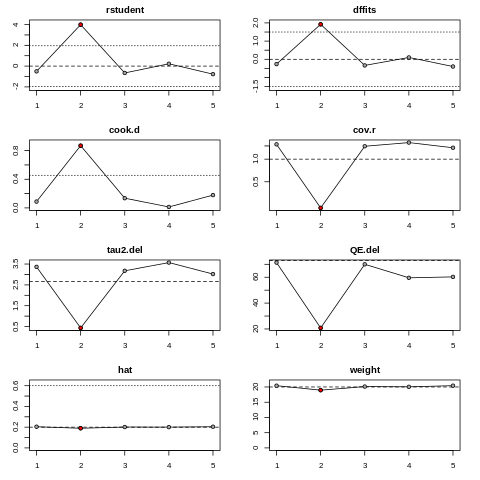

In [ ]:
%%R

# ============================================
# TNF-α DATA (5 studies)
# ============================================
tnf_study <- c("Eller 2008", "OBrien 2007", "Yoshimura 2009", "Tuglu 2003", "Bot 2011")
tnf_SMD <- c(0.38, 4.10, 0.15, 1.60, 0.00)
tnf_SE  <- c(0.20, 0.50, 0.28, 0.30, 0.20)
tnf_n   <- c(100, 52, 51, 43, 50)

tnf_meta <- metagen(TE = tnf_SMD, seTE = tnf_SE, studlab = tnf_study, sm = "SMD", method.tau = "REML")
tnf_res <- rma(yi = tnf_SMD, sei = tnf_SE, method = "REML", slab = tnf_study)

# FIGURE 9: Forest Plot
forest(tnf_meta,
       xlab = "Effect Size (SMD)",
       main = "TNF-a and Antidepressant Response",
       leftcols = c("studlab"),
       rightcols = c("effect", "ci"),
       col.diamond = "black",
       col.square = "black")

# FIGURE 10: Funnel Plot
funnel(tnf_meta,
       xlab = "Effect Size (SMD)",
       ylab = "Standard Error",
       main = "Funnel Plot: TNF-a Studies")

# FIGURE 11: Leave-One-Out Plot
tnf_loo <- leave1out(tnf_res)
forest(x = tnf_loo$estimate,
       sei = tnf_loo$se,
       slab = tnf_study,
       xlab = "Effect Size (SMD)",
       main = "Leave-One-Out Analysis: TNF-a",
       refline = tnf_res$b)

# FIGURE 12: Baujat Plot
inf_tnf <- influence(tnf_res)
plot(inf_tnf)

# Summary statistics
print(tnf_meta)
cat("\nI-squared = ", round(tnf_meta$I2, 1), "%\n")

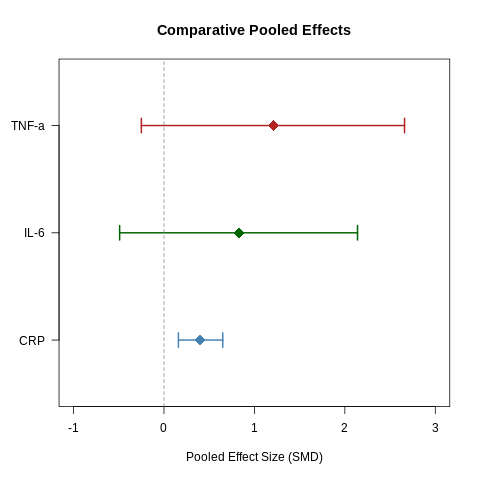

In [ ]:
%%R

# ============================================
# POOLED EFFECTS COMPARISON
# ============================================
pooled_SMD <- c(0.40, 0.83, 1.21)
pooled_lower <- c(0.16, -0.49, -0.25)
pooled_upper <- c(0.65, 2.14, 2.66)
markers <- c("CRP", "IL-6", "TNF-a")

plot(pooled_SMD, 1:3,
     xlim = c(-1, 3),
     ylim = c(0.5, 3.5),
     yaxt = "n",
     ylab = "",
     xlab = "Pooled Effect Size (SMD)",
     main = "Comparative Pooled Effects",
     pch = 18,
     cex = 2,
     col = c("steelblue", "darkgreen", "firebrick"))

axis(2, at = 1:3, labels = markers, las = 1)

arrows(pooled_lower, 1:3, pooled_upper, 1:3,
       angle = 90, code = 3, length = 0.1,
       lwd = 2, col = c("steelblue", "darkgreen", "firebrick"))

abline(v = 0, lty = 2, col = "gray50")

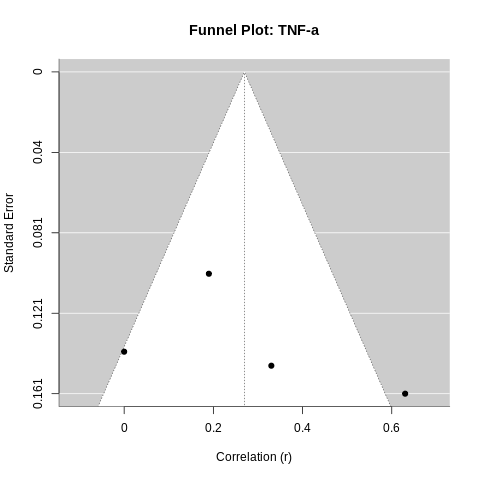

In [ ]:
%%R

library(metafor)

# CRP data
crp_study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Tuglu 2003")
crp_r <- c(0.21, 0.29, 0.30, 0.00)
crp_n <- c(115, 51, 75, 26)
crp_se <- c(0.094, 0.145, 0.118, 0.196)

crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS")

# IL-6 data
il6_study <- c("Yoshimura 2009", "O'Brien 2007")
il6_r <- c(0.29, 0.28)
il6_n <- c(51, 52)
il6_se <- c(0.145, 0.144)

il6_res <- rma(yi = il6_r, sei = il6_se, method = "HS")

# TNF-a data
tnf_study <- c("Eller 2008", "O'Brien 2007", "Yoshimura 2009", "Tuglu 2003")
tnf_r <- c(0.19, 0.33, 0.00, 0.63)
tnf_n <- c(100, 52, 51, 43)
tnf_se <- c(0.101, 0.147, 0.140, 0.161)

tnf_res <- rma(yi = tnf_r, sei = tnf_se, method = "HS")

# Generate forest plots
forest(crp_res, slab = crp_study, xlab = "Correlation (r)", main = "CRP and Antidepressant Response")
forest(il6_res, slab = il6_study, xlab = "Correlation (r)", main = "IL-6 and Antidepressant Response")
forest(tnf_res, slab = tnf_study, xlab = "Correlation (r)", main = "TNF-a and Antidepressant Response")

# Generate funnel plots
funnel(crp_res, xlab = "Correlation (r)", main = "Funnel Plot: CRP")
funnel(il6_res, xlab = "Correlation (r)", main = "Funnel Plot: IL-6")
funnel(tnf_res, xlab = "Correlation (r)", main = "Funnel Plot: TNF-a")

[1] "CRP Pooled Result:"
[1] "r = 0.23 95% CI: 0.11 to 0.35"


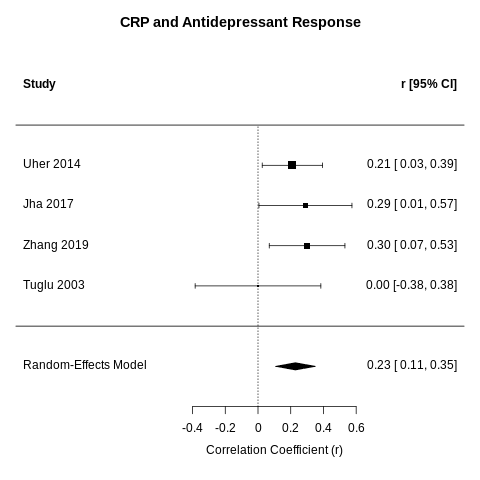

In [ ]:
%%R

library(metafor)

# CRP data
crp_study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Tuglu 2003")
crp_r <- c(0.21, 0.29, 0.30, 0.00)
crp_n <- c(115, 51, 75, 26)
crp_se <- c(0.094, 0.145, 0.118, 0.196)

# Run meta-analysis
crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS", weighted = TRUE)

# Create forest plot
forest(crp_res,
       slab = crp_study,
       xlab = "Correlation Coefficient (r)",
       main = "CRP and Antidepressant Response",
       header = c("Study", "r [95% CI]"))

# Show the pooled result
print("CRP Pooled Result:")
print(paste("r =", round(crp_res$b, 2), "95% CI:", round(crp_res$ci.lb, 2), "to", round(crp_res$ci.ub, 2)))

[1] "IL-6 Pooled Result:"
[1] "r = 0.28 95% CI: 0.08 to 0.49"


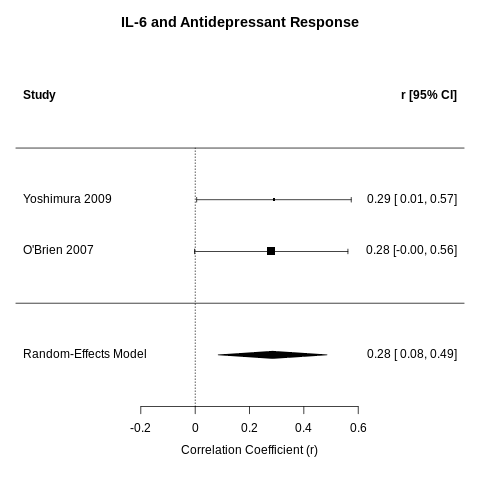

In [ ]:
%%R

library(metafor)

# IL-6 data
il6_study <- c("Yoshimura 2009", "O'Brien 2007")
il6_r <- c(0.29, 0.28)
il6_n <- c(51, 52)
il6_se <- c(0.145, 0.144)

# Run meta-analysis
il6_res <- rma(yi = il6_r, sei = il6_se, method = "HS", weighted = TRUE)

# Create forest plot
forest(il6_res,
       slab = il6_study,
       xlab = "Correlation Coefficient (r)",
       main = "IL-6 and Antidepressant Response",
       header = c("Study", "r [95% CI]"))

# Show the pooled result
print("IL-6 Pooled Result:")
print(paste("r =", round(il6_res$b, 2), "95% CI:", round(il6_res$ci.lb, 2), "to", round(il6_res$ci.ub, 2)))

[1] "TNF-a Pooled Result:"
[1] "r = 0.27 95% CI: 0.07 to 0.47"


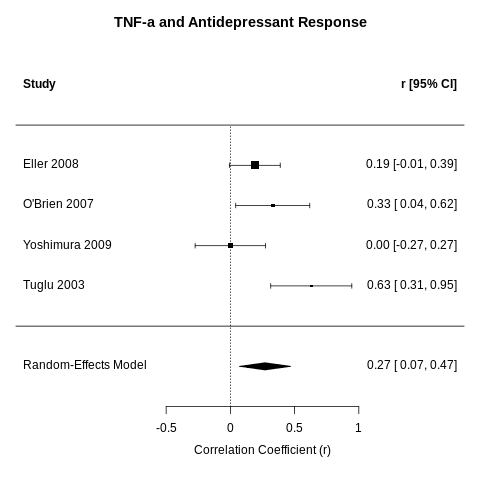

In [ ]:
%%R

library(metafor)

# TNF-alpha data
tnf_study <- c("Eller 2008", "O'Brien 2007", "Yoshimura 2009", "Tuglu 2003")
tnf_r <- c(0.19, 0.33, 0.00, 0.63)
tnf_n <- c(100, 52, 51, 43)
tnf_se <- c(0.101, 0.147, 0.140, 0.161)

# Run meta-analysis
tnf_res <- rma(yi = tnf_r, sei = tnf_se, method = "HS", weighted = TRUE)

# Create forest plot
forest(tnf_res,
       slab = tnf_study,
       xlab = "Correlation Coefficient (r)",
       main = "TNF-a and Antidepressant Response",
       header = c("Study", "r [95% CI]"))

# Show the pooled result
print("TNF-a Pooled Result:")
print(paste("r =", round(tnf_res$b, 2), "95% CI:", round(tnf_res$ci.lb, 2), "to", round(tnf_res$ci.ub, 2)))

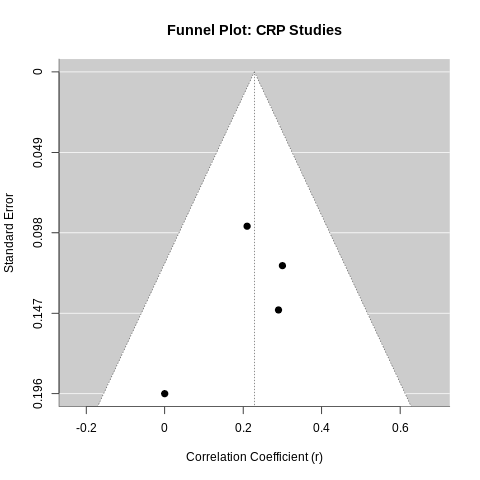

In [ ]:
%%R

library(metafor)

# CRP data again
crp_study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Tuglu 2003")
crp_r <- c(0.21, 0.29, 0.30, 0.00)
crp_se <- c(0.094, 0.145, 0.118, 0.196)

crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS")

# Create funnel plot
funnel(crp_res,
       xlab = "Correlation Coefficient (r)",
       ylab = "Standard Error",
       main = "Funnel Plot: CRP Studies",
       cex = 1.2,
       pch = 19)

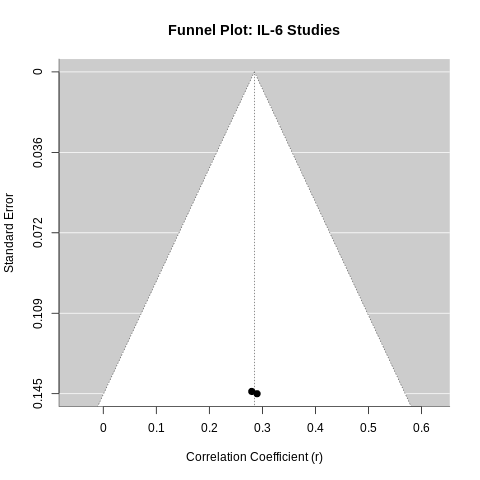

In [ ]:
%%R

library(metafor)

# IL-6 data again
il6_study <- c("Yoshimura 2009", "O'Brien 2007")
il6_r <- c(0.29, 0.28)
il6_se <- c(0.145, 0.144)

il6_res <- rma(yi = il6_r, sei = il6_se, method = "HS")

# Create funnel plot
funnel(il6_res,
       xlab = "Correlation Coefficient (r)",
       ylab = "Standard Error",
       main = "Funnel Plot: IL-6 Studies",
       cex = 1.2,
       pch = 19)

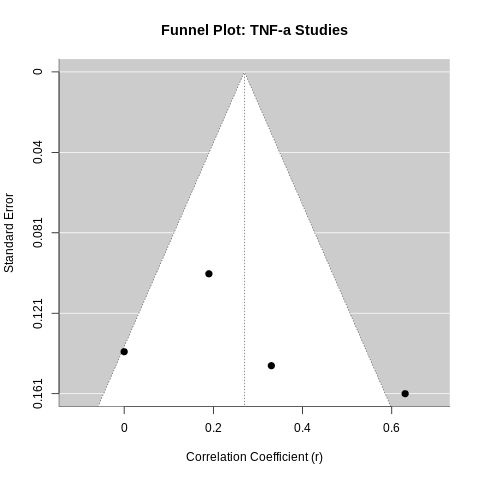

In [ ]:
%%R

library(metafor)

# TNF-alpha data again
tnf_study <- c("Eller 2008", "O'Brien 2007", "Yoshimura 2009", "Tuglu 2003")
tnf_r <- c(0.19, 0.33, 0.00, 0.63)
tnf_se <- c(0.101, 0.147, 0.140, 0.161)

tnf_res <- rma(yi = tnf_r, sei = tnf_se, method = "HS")

# Create funnel plot
funnel(tnf_res,
       xlab = "Correlation Coefficient (r)",
       ylab = "Standard Error",
       main = "Funnel Plot: TNF-a Studies",
       cex = 1.2,
       pch = 19)


=== CRP LEAVE-ONE-OUT ===

   estimate     se   zval   pval  ci.lb  ci.ub      Q     Qp   tau2     I2 
-1   0.2430 0.0829 2.9306 0.0034 0.0805 0.4056 1.8755 0.3915 0.0000 0.0000 
-2   0.2147 0.0688 3.1192 0.0018 0.0798 0.3496 1.7250 0.4221 0.0000 0.0000 
-3   0.2011 0.0732 2.7483 0.0060 0.0577 0.3445 1.4376 0.4873 0.0000 0.0000 
-4   0.2542 0.0656 3.8758 0.0001 0.1256 0.3827 0.4327 0.8055 0.0000 0.0000 
       H2 
-1 1.0000 
-2 1.0000 
-3 1.0000 
-4 1.0000 


=== IL-6 LEAVE-ONE-OUT ===

   estimate     se   zval   pval   ci.lb  ci.ub      Q     Qp   tau2     I2 
-1   0.2800 0.1440 1.9444 0.0518 -0.0022 0.5622 0.0000 1.0000 0.0000 0.0000 
-2   0.2900 0.1450 2.0000 0.0455  0.0058 0.5742 0.0000 1.0000 0.0000 0.0000 
       H2 
-1 1.0000 
-2 1.0000 


=== TNF-α LEAVE-ONE-OUT ===

   estimate     se   zval   pval  ci.lb  ci.ub      Q     Qp   tau2      I2 
-1   0.3100 0.1474 2.1038 0.0354 0.0212 0.5988 8.8243 0.0121 0.0429 65.8588 
-2   0.2549 0.1289 1.9776 0.0480 0.0023 0.5076 9.0282 0.01

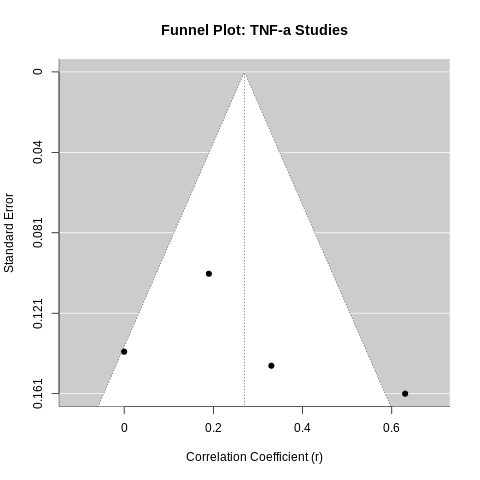

In [ ]:
%%R

# Load required packages
library(metafor)

# ============================================
# CRP META-ANALYSIS
# ============================================

crp_study <- c("Uher 2014", "Jha 2017", "Zhang 2019", "Tuglu 2003")
crp_r <- c(0.21, 0.29, 0.30, 0.00)
crp_n <- c(115, 51, 75, 26)
crp_se <- c(0.094, 0.145, 0.118, 0.196)

crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS", weighted = TRUE)

# FIGURE 2: CRP Forest Plot
forest(crp_res,
       slab = crp_study,
       xlab = "Correlation Coefficient (r)",
       main = "CRP and Antidepressant Response",
       header = c("Study", "r [95% CI]"),
       col = "black")

# ============================================
# IL-6 META-ANALYSIS
# ============================================

il6_study <- c("Yoshimura 2009", "O'Brien 2007")
il6_r <- c(0.29, 0.28)
il6_n <- c(51, 52)
il6_se <- c(0.145, 0.144)

il6_res <- rma(yi = il6_r, sei = il6_se, method = "HS", weighted = TRUE)

# FIGURE 3: IL-6 Forest Plot
forest(il6_res,
       slab = il6_study,
       xlab = "Correlation Coefficient (r)",
       main = "IL-6 and Antidepressant Response",
       header = c("Study", "r [95% CI]"),
       col = "black")

# ============================================
# TNF-α META-ANALYSIS
# ============================================

tnf_study <- c("Eller 2008", "O'Brien 2007", "Yoshimura 2009", "Tuglu 2003")
tnf_r <- c(0.19, 0.33, 0.00, 0.63)
tnf_n <- c(100, 52, 51, 43)
tnf_se <- c(0.101, 0.147, 0.140, 0.161)

tnf_res <- rma(yi = tnf_r, sei = tnf_se, method = "HS", weighted = TRUE)

# FIGURE 4: TNF-α Forest Plot
forest(tnf_res,
       slab = tnf_study,
       xlab = "Correlation Coefficient (r)",
       main = "TNF-a and Antidepressant Response",
       header = c("Study", "r [95% CI]"),
       col = "black")

# ============================================
# FIGURE 5: CRP Funnel Plot
# ============================================

funnel(crp_res,
       xlab = "Correlation Coefficient (r)",
       ylab = "Standard Error",
       main = "Funnel Plot: CRP Studies")

# ============================================
# FIGURE 6: IL-6 Funnel Plot
# ============================================

funnel(il6_res,
       xlab = "Correlation Coefficient (r)",
       ylab = "Standard Error",
       main = "Funnel Plot: IL-6 Studies")

# ============================================
# FIGURE 7: TNF-α Funnel Plot
# ============================================

funnel(tnf_res,
       xlab = "Correlation Coefficient (r)",
       ylab = "Standard Error",
       main = "Funnel Plot: TNF-a Studies")

# ============================================
# LEAVE-ONE-OUT ANALYSIS (for text reporting)
# ============================================

cat("\n=== CRP LEAVE-ONE-OUT ===\n")
print(leave1out(crp_res))

cat("\n=== IL-6 LEAVE-ONE-OUT ===\n")
print(leave1out(il6_res))

cat("\n=== TNF-α LEAVE-ONE-OUT ===\n")
print(leave1out(tnf_res))

[1] "=== COMBINED INFLAMMATION INDEX ==="
[1] "Pooled r = 0.248"
[1] "95% CI: 0.16 to 0.336"
[1] "p-value = 0"
[1] "I² = 13.4 %"


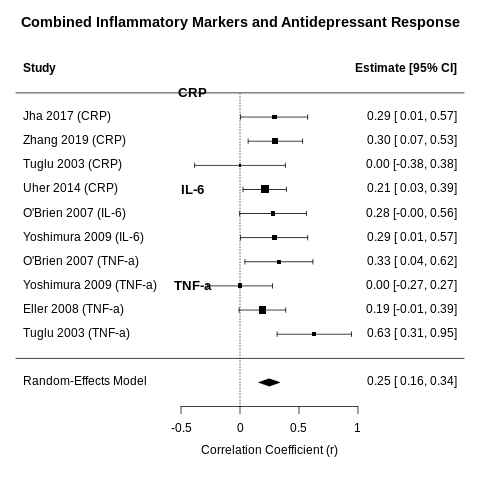

In [ ]:
%%R

library(metafor)

# Combine all studies across all three markers
all_study <- c("Uher 2014 (CRP)", "Jha 2017 (CRP)", "Zhang 2019 (CRP)", "Tuglu 2003 (CRP)",
               "Yoshimura 2009 (IL-6)", "O'Brien 2007 (IL-6)",
               "Eller 2008 (TNF-a)", "O'Brien 2007 (TNF-a)", "Yoshimura 2009 (TNF-a)", "Tuglu 2003 (TNF-a)")

all_r <- c(0.21, 0.29, 0.30, 0.00,
           0.29, 0.28,
           0.19, 0.33, 0.00, 0.63)

all_n <- c(115, 51, 75, 26,
           51, 52,
           100, 52, 51, 43)

all_se <- c(0.094, 0.145, 0.118, 0.196,
            0.145, 0.144,
            0.101, 0.147, 0.140, 0.161)

# Create a subgroup variable
subgroup <- c(rep("CRP", 4), rep("IL-6", 2), rep("TNF-a", 4))

# Run meta-analysis on all studies combined
all_res <- rma(yi = all_r, sei = all_se, method = "HS")

# Forest plot with subgroups
forest(all_res,
       slab = all_study,
       xlab = "Correlation Coefficient (r)",
       main = "Combined Inflammatory Markers and Antidepressant Response",
       order = order(subgroup, all_r))

# Add subgroup labels
text(-0.4, 11, "CRP", font = 2, cex = 1.1)
text(-0.4, 7, "IL-6", font = 2, cex = 1.1)
text(-0.4, 3, "TNF-a", font = 2, cex = 1.1)

# Show the pooled result
print("=== COMBINED INFLAMMATION INDEX ===")
print(paste("Pooled r =", round(all_res$b, 3)))
print(paste("95% CI:", round(all_res$ci.lb, 3), "to", round(all_res$ci.ub, 3)))
print(paste("p-value =", round(all_res$pval, 4)))
print(paste("I² =", round(all_res$I2, 1), "%"))

In [ ]:
%%R

# Re-run individual analyses for comparison
crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS")
il6_res <- rma(yi = il6_r, sei = il6_se, method = "HS")
tnf_res <- rma(yi = tnf_r, sei = tnf_se, method = "HS")

cat("\n\n=== COMPARISON: INDIVIDUAL MARKERS vs COMBINED INDEX ===\n\n")

cat("CRP alone:\n")
cat("  r =", round(crp_res$b, 3), "95% CI:", round(crp_res$ci.lb, 3), "to", round(crp_res$ci.ub, 3), "\n\n")

cat("IL-6 alone:\n")
cat("  r =", round(il6_res$b, 3), "95% CI:", round(il6_res$ci.lb, 3), "to", round(il6_res$ci.ub, 3), "\n\n")

cat("TNF-a alone:\n")
cat("  r =", round(tnf_res$b, 3), "95% CI:", round(tnf_res$ci.lb, 3), "to", round(tnf_res$ci.ub, 3), "\n\n")

cat("COMBINED INDEX (all 10 studies):\n")
cat("  r =", round(all_res$b, 3), "95% CI:", round(all_res$ci.lb, 3), "to", round(all_res$ci.ub, 3), "\n")
cat("  I² =", round(all_res$I2, 1), "%\n\n")



=== COMPARISON: INDIVIDUAL MARKERS vs COMBINED INDEX ===

CRP alone:
  r = 0.229 95% CI: 0.107 to 0.35 

IL-6 alone:
  r = 0.285 95% CI: 0.085 to 0.485 

TNF-a alone:
  r = 0.27 95% CI: 0.07 to 0.469 

COMBINED INDEX (all 10 studies):
  r = 0.248 95% CI: 0.16 to 0.336 
  I² = 13.4 %



In [ ]:
%%R
crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS")
crp_loo <- leave1out(crp_res)
forest(crp_loo, slab = crp_study, xlab = "Correlation (r)",
       main = "Leave-One-Out Analysis: CRP Studies")

Error in forest.default(crp_loo, slab = crp_study, xlab = "Correlation (r)",  : 
  Must specify either 'vi', 'sei', or ('ci.lb','ci.ub').


RInterpreterError: Failed to parse and evaluate line 'crp_res <- rma(yi = crp_r, sei = crp_se, method = "HS")\ncrp_loo <- leave1out(crp_res)\nforest(crp_loo, slab = crp_study, xlab = "Correlation (r)", \n       main = "Leave-One-Out Analysis: CRP Studies")\n'.
R error message: 'Error in forest.default(crp_loo, slab = crp_study, xlab = "Correlation (r)",  : \n  Must specify either \'vi\', \'sei\', or (\'ci.lb\',\'ci.ub\').'